In [29]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
from src.exp_cleaner import open_all_xps_files, fill_spectral_data
from src.utils import create_uniform_energy_grid
import json

In [ ]:
data_path = Path("../data/experimental_data")
polymers = os.listdir(data_path) # Use the first 106 polymers
unknown_copolymers = ['poly(ethylene-co-maleic anhydride) (PECMA)', 'poly(styrene-co-maleic anhydride) (PSCMA)' ]

# Remove copolymers with unkown quantities from the polymers list
polymers = [p for p in polymers if p not in unknown_copolymers]


# Load the data
spectral_data, label_data, ids, be_data, SMILES_data = open_all_xps_files(data_path=data_path, elements=polymers)

Material ID: poly(ether ether ketone) (PEEK)
Material ID: poly(vinyl methyl ether) (PVME)
Material ID: poly(4-hydroxystyrene) (PHS)
Material ID: poly(ethyl methacrylate) (PEMA)
Material ID: poly(methyl methacrylate) (PMMA)
Material ID: poly(trans-isoprene) (PtI)
Material ID: poly(glycolide) (PG)
Material ID: Ethylcellulose (ECEL)
Material ID: poly(allylamine hydrochloride) (PAAMC)
Material ID: poly(trifluoroethyl acrylate) (PTFEA)
Material ID: poly(lauryl methacrylate) (PLMA)
Material ID: poly(vinyl ethyl ether) (PVEE)
Material ID: Nylon 6,6 (N66)
Material ID: p-Quaterphenyl [poly(phenylene) oligomer]
Material ID: poly(d,l-lactide) (PL)
Material ID: poly(ethylene sulphide) (PETHS)
Material ID: poly(diallyl isophthalate) (PDAiP)
Material ID: poly(vinyl acetate) (PVAc)
Material ID: poly(methacrylamide) (PMAM)
Material ID: poly(propylene glycol) (PPG)
Material ID: poly(chloroprene) (PCP)
Material ID: poly(4-methyl-1-pentene) (PMP)
Material ID: poly(vinylidine chloride) (PVdC)
Material ID:

In [30]:
start_energy = 0  # Define your start energy
end_energy = 700  # Define your end energy
increment = 0.1  # Define your energy increment

# Fill gaps in the spectral data
filled_spectral_data = fill_spectral_data(
    cps_data= spectral_data,  # CPS dictionary
    be_data=be_data,   # BE dictionary
    start_energy=start_energy,
    end_energy=end_energy,
    increment=increment
)


example name: poly(vinyl methyl ether) (PVME)
ether (aliphatic)


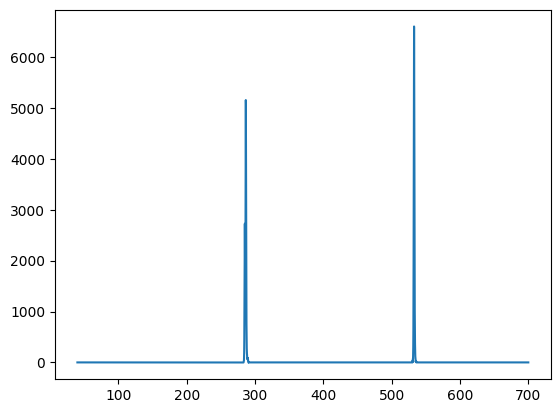

In [ ]:
i = 1
example = ids[i]
print(f'example name: {example}')

example_spectra = filled_spectral_data[example]
core_example_spectra =example_spectra[400:]
example_label = label_data[example]


with open("FG_list.json", "r") as f:
    FG_list = json.load(f)

for n, fg in enumerate(example_label):
    if fg == 1:
        print(FG_list[n])

start_energy = 40
end_energy = 700
BE_values = create_uniform_energy_grid(start_energy, end_energy)

plt.plot(BE_values, core_example_spectra)

In [36]:
import json
# Assuming 'ids', 'label_data', and 'FG_list' are already loaded as in your script

# 1. Initialize a dictionary with each FG name as a key and an empty list as its value
polymers_by_fg = {fg_name: [] for fg_name in FG_list}

# 2. Iterate through each polymer ID
for polymer_id in ids:
    # Get the label (the list of 40 FG counts) for the current polymer
    label = label_data[polymer_id]
    
    # 3. Iterate through the counts in the label, keeping track of the index
    # The index corresponds to the position in your FG_list
    for index, count in enumerate(label):
        # 4. If the count for an FG is positive (meaning it's present)
        if count > 0:
            # Get the name of the functional group using the index
            fg_name = FG_list[index]
            # Add the current polymer's ID to the list for that FG
            polymers_by_fg[fg_name].append(polymer_id)

# Now you have a complete dictionary. You can inspect it.
# For example, to see all polymers with a 'Carboxylic Acid' group (if that's in your list):
# print(polymers_by_fg['Carboxylic Acid'])



alcohol (aromatic)
['poly(4-hydroxystyrene) (PHS)']


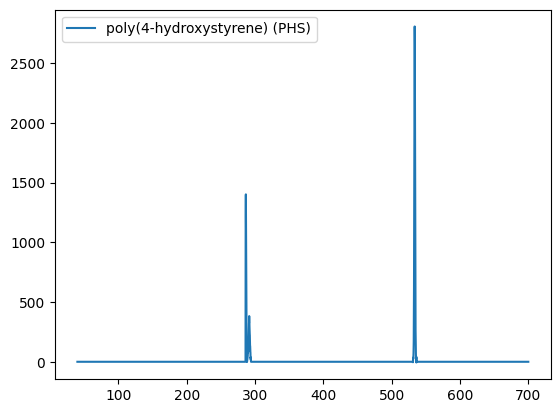

In [110]:
fg_index = 5


fg = list(polymers_by_fg.keys())[fg_index]
print(fg)

polymers_of_interest = polymers_by_fg[fg]
print(polymers_of_interest)


for polymer in polymers_of_interest:
    whole_spectra = filled_spectral_data[polymer]
    core_spectra =whole_spectra[400:]
    plt.plot(BE_values, core_spectra, label=polymer)



plt.xlim()
plt.ylim() 
plt.legend()

plt.show()

In [66]:
print(polymers_by_fg['alkyl halide (Cl)'])

['poly(chloroprene) (PCP)', 'poly(vinylidine chloride) (PVdC)', 'Poly(2-chloroethyl methacrylate) (PCEMA)', 'poly(vinyl chloride) (PVC)']


## Inactive FGs in all labels:

In [70]:
all_fgs = polymers_by_fg.keys()

for fg in all_fgs:
    if polymers_by_fg[fg] == []:
        print(fg)

alkyne
alkyl halide (Br)
alkyl halide (I)
thiol
aldehyde
nitrite
acid chloride
azide
alkane
